In [15]:
#!pip install georinex

Loaded OBS: 55251350.26o
Epochs: 510, Satellites listed: 37
SNR field: None


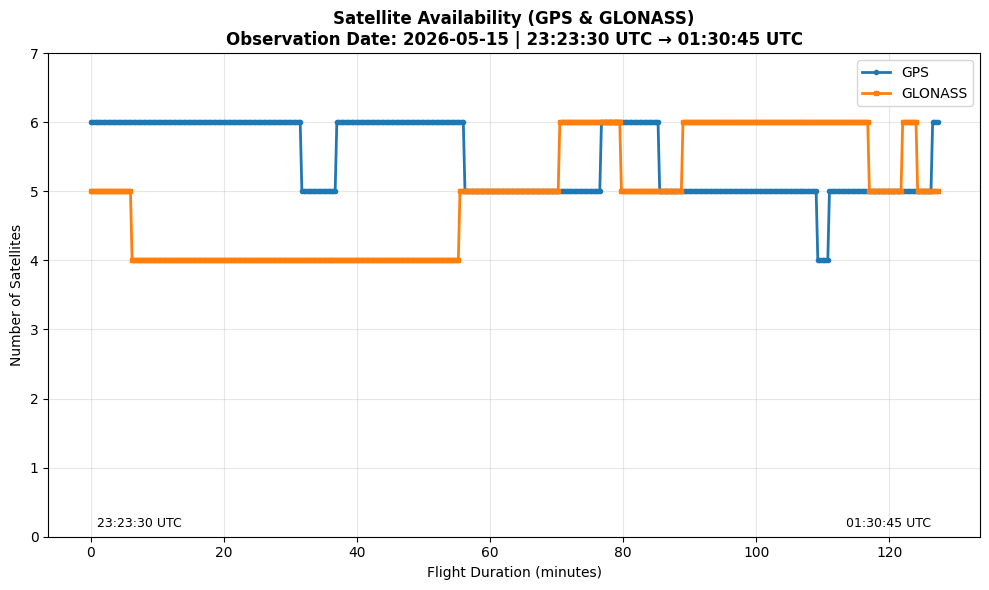


SUMMARY
Observation date : 2026-05-15
UTC start        : 23:23:30 UTC
UTC end          : 01:30:45 UTC
Observation duration : 127.2 minutes
Y-axis max used  : 7
GPS      max/min : 6 / 4
GLONASS max/min : 6 / 4


In [17]:
# ============================================================
# SINGLE NOTEBOOK CELL — RINEX Quality Metrics (GPS + GLONASS)
# Y-axis from 0, integer ticks, y-max = (max satellites + 1)
# Date + UTC start/end on plot
# ============================================================

from pathlib import Path
import re, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import georinex as gr
from matplotlib.ticker import MaxNLocator
import warnings
warnings.filterwarnings('ignore')

# -----------------------------
# CONFIG
# -----------------------------
DATA_DIR = Path(r"C:\Farid\TEMP\260515_RINEX_55251350")  # <-- update if needed
PLOT_FIGSIZE = (10, 6)

# -----------------------------
# HELPERS
# -----------------------------
def find_obs_files(d):
    obs = []
    for f in d.glob("*"):
        if not f.is_file():
            continue
        name = f.name
        if name.lower().endswith((".gz",".z",".zip",".bz2")):
            name = os.path.splitext(name)[0]
        if re.match(r".*\.[0-9]{2}[oOdD]$", name) or name.lower().endswith((".obs",".rnx",".crx")):
            obs.append(f)
    return sorted(obs)

def constellation_from_sv(sv):
    p = str(sv)[0].upper()
    if p == 'G': return 'GPS'
    if p == 'R': return 'GLONASS'
    return None

def pick_snr_var(obs):
    for p in ['S1C','S1','S2','S5']:
        if p in obs.data_vars:
            return p
    for v in obs.data_vars:
        if v.upper().startswith('S'):
            return v
    return None

def has_valid_obs(obs, t, sv):
    for k in ['C1C','L1C','C1','L1','P1','P2']:
        if k in obs.data_vars:
            v = obs[k].sel(time=t, sv=sv).values
            if not np.isnan(v):
                return True
    return False

# -----------------------------
# LOAD RINEX OBS
# -----------------------------
obs_files = find_obs_files(DATA_DIR)
if not obs_files:
    raise FileNotFoundError("No RINEX observation files found.")

obs = gr.load(obs_files[0])
snr_var = pick_snr_var(obs)

print(f"Loaded OBS: {obs_files[0].name}")
print(f"Epochs: {len(obs.time)}, Satellites listed: {len(obs.sv)}")
print(f"SNR field: {snr_var}")

# -----------------------------
# EXTRACT (GPS + GLONASS ONLY)
# -----------------------------
rows = []
for t in obs.time:
    tdt = pd.to_datetime(str(t.values))
    for sv in obs.sv.values:
        const = constellation_from_sv(sv)
        if const is None:
            continue
        if has_valid_obs(obs, t, sv):
            row = {'time': tdt, 'constellation': const}
            if snr_var:
                row['snr'] = obs[snr_var].sel(time=t, sv=sv).values
            rows.append(row)

df = pd.DataFrame(rows)
if df.empty:
    raise ValueError("No valid GPS or GLONASS observations found.")

# -----------------------------
# AGGREGATE
# -----------------------------
sat_cnt = df.groupby(['time','constellation']).size().unstack(fill_value=0)

t_start = sat_cnt.index[0]
t_end   = sat_cnt.index[-1]
sat_cnt['flight_min'] = (sat_cnt.index - t_start).total_seconds() / 60.0

avg_snr = None
if snr_var and 'snr' in df and not df['snr'].isna().all():
    avg_snr = df.groupby(['time','constellation'])['snr'].mean().unstack()
    avg_snr['flight_min'] = (avg_snr.index - t_start).total_seconds() / 60.0

# Date + UTC strings
obs_date_str = t_start.strftime("%Y-%m-%d")
utc_start_str = t_start.strftime("%H:%M:%S UTC")
utc_end_str   = t_end.strftime("%H:%M:%S UTC")

# -----------------------------
# Y-AXIS MAX = (MAX SAT + 1)
# -----------------------------
sat_max = 0
if 'GPS' in sat_cnt:
    sat_max = max(sat_max, int(sat_cnt['GPS'].max()))
if 'GLONASS' in sat_cnt:
    sat_max = max(sat_max, int(sat_cnt['GLONASS'].max()))
ymax_sat = sat_max + 1

# -----------------------------
# PLOT
# -----------------------------
colors = {'GPS':'#1f77b4', 'GLONASS':'#ff7f0e'}

fig, axes = plt.subplots(2 if avg_snr is not None else 1, 1, figsize=PLOT_FIGSIZE)
if not isinstance(axes, (list, np.ndarray)):
    axes = [axes]

# ---- Satellite count ----
ax = axes[0]
if 'GPS' in sat_cnt:
    ax.plot(sat_cnt['flight_min'], sat_cnt['GPS'],
            label='GPS', color=colors['GPS'], lw=2, marker='o', ms=3)
if 'GLONASS' in sat_cnt:
    ax.plot(sat_cnt['flight_min'], sat_cnt['GLONASS'],
            label='GLONASS', color=colors['GLONASS'], lw=2, marker='s', ms=3)

ax.set_xlabel("Flight Duration (minutes)")
ax.set_ylabel("Number of Satellites")
ax.set_ylim(0, ymax_sat)
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_title(
    f"Satellite Availability (GPS & GLONASS)\n"
    f"Observation Date: {obs_date_str} | {utc_start_str} → {utc_end_str}",
    fontweight='bold'
)
ax.grid(True, alpha=0.3)
ax.legend(loc='best')

# annotate start/end times
ax.annotate(utc_start_str, xy=(0, 0), xycoords=('data','axes fraction'),
            xytext=(5, 5), textcoords='offset points',
            ha='left', va='bottom', fontsize=9)
ax.annotate(utc_end_str, xy=(sat_cnt['flight_min'].max(), 0),
            xycoords=('data','axes fraction'),
            xytext=(-5, 5), textcoords='offset points',
            ha='right', va='bottom', fontsize=9)

# ---- SNR/CN0 ----
if avg_snr is not None:
    ax = axes[1]
    if 'GPS' in avg_snr:
        ax.plot(avg_snr['flight_min'], avg_snr['GPS'],
                label='GPS', color=colors['GPS'], lw=2, marker='o', ms=3)
    if 'GLONASS' in avg_snr:
        ax.plot(avg_snr['flight_min'], avg_snr['GLONASS'],
                label='GLONASS', color=colors['GLONASS'], lw=2, marker='s', ms=3)

    ax.axhline(35, color='orange', ls='--', lw=1.5, alpha=0.6,
               label='Good Signal (35 dB-Hz)')
    ax.set_xlabel("Observation Duration (minutes)")
    ax.set_ylabel("Avg SNR / C/N₀ (dB-Hz)")
    ax.set_ylim(bottom=0)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set_title("Signal Quality (GPS & GLONASS)", fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best')

plt.tight_layout()
plt.show()

# -----------------------------
# QUICK SUMMARY
# -----------------------------
print("\n" + "="*60)
print("SUMMARY")
print("="*60)
print(f"Observation date : {obs_date_str}")
print(f"UTC start        : {utc_start_str}")
print(f"UTC end          : {utc_end_str}")
print(f"Observation duration : {sat_cnt['flight_min'].max():.1f} minutes")
print(f"Y-axis max used  : {ymax_sat}")
if 'GPS' in sat_cnt:
    print(f"GPS      max/min : {sat_cnt['GPS'].max()} / {sat_cnt['GPS'].min()}")
if 'GLONASS' in sat_cnt:
    print(f"GLONASS max/min : {sat_cnt['GLONASS'].max()} / {sat_cnt['GLONASS'].min()}")
print("="*60)
